# Gallstone Disease Risk Prediction Using Machine Learning
**Capstone Notebook — QM640: Data Analytics Capstone**

**Author:** Prasun Das · **Institution:** Walsh College · **Mentor:** Arun K. Sharma

This notebook contains the solution for the four research questions defined in the "Gallstone Disease Risk Prediction Using Machine Learning" synopsis:

* **RQ1** Feature distribution and differences between gallstone vs non-gallstone patients
* **RQ2** Body-composition trends across BMI categories
* **RQ3** Association between obesity (BMI ≥ 30 kg/m²) and gallstone presence
* **RQ4** Predictive modelling of gallstone status with Logistic Regression and Random Forest

The dataset is the UCI *Gallstone-1* dataset (ID 1150). It was sourced from the UCI repository and uploaded to Google Drive for convenient access and seamless notebook execution.



## 1. Setup and Environment

In [1]:
# Import essential Python libraries for data handling, visualization, statistical testing, preprocessing, model building (logistic regression, random forest), evaluation metrics, cross-validation, and class imbalance handling using SMOTE.

import os, io, json, warnings, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import google.colab as colab

from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact, spearmanr
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110})
RANDOM_STATE = 42
print('Libraries loaded successfully.')


Libraries loaded successfully.


## 2. Load the Gallstone Dataset

The primary source is the UCI Machine Learning Repository (Dataset ID 1150).
Loading the local dataset - 'dataset-uci.xlsx' that is shipped/downloaded from the UCI Machine Learning Repository (Dataset ID 1150).

Dataset link - https://archive.ics.uci.edu/dataset/1150/gallstone-1

This dataset has been uploaded to Google Drive for easy access and quick execution.

In [2]:
# Mounting the google drive to access the Gallstone dataset
colab.drive.mount('/content/drive')

# Configure the dataset file path and read the dataset
file_path = "/content/drive/My Drive/Colab Notebooks/MS/Capstone/dataset-uci.xlsx"

Mounted at /content/drive


In [3]:
# Load the dataset
df = pd.read_excel(file_path, sheet_name="dataset")
df.head()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,27.1,52.9,21.2,31.7,40.0,19.2,80.84,18.88,9,3.7,71.4,23.4,17.8,10.6,39.7,0,102.0,250.0,175.0,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,30.5,43.1,19.5,23.6,45.0,32.8,67.20,16.68,15,3.2,60.3,38.8,31.0,18.4,32.7,0,94.0,172.0,108.0,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,31.2,47.2,20.1,27.1,43.0,27.3,72.67,16.35,15,3.3,62.9,41.7,24.9,16.2,34.0,0,103.0,179.0,124.0,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,24.0,41.4,17.0,24.4,41.0,15.8,84.19,16.90,6,2.9,54.1,9.0,10.7,6.5,29.2,1,69.0,173.0,73.0,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,28.3,51.4,20.0,31.4,39.0,20.0,80.02,16.81,8,3.5,68.2,28.6,17.9,10.4,37.4,2,109.0,205.0,154.0,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [4]:
# Printing the shape of the dataset and the info
print('Shape:', df.shape)

# Basic stats & nulls
display(df.describe(include='all'))

Shape: (319, 39)


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.00000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,0.495298,48.068966,0.492163,0.335423,0.037618,0.028213,0.025078,0.134796,167.15674,80.564890,28.877116,40.587774,17.071160,23.634483,42.212038,28.274984,71.638245,15.938809,9.078370,2.803292,54.273041,35.850125,23.487774,12.171599,30.403448,1.150470,108.688715,203.495298,126.652351,49.475549,144.502163,21.684953,26.855799,73.112539,0.800611,100.818903,1.853856,14.418182,21.401411
std,0.500763,12.114558,0.500724,0.517340,0.190568,0.165841,0.156609,0.342042,10.05303,15.709069,5.313707,7.930235,3.161857,5.349332,3.244470,8.444417,8.437598,2.334744,4.332501,0.509467,10.603833,109.799718,9.607607,5.262178,4.460530,1.059217,44.848714,45.758501,38.541175,17.718701,97.904493,16.697605,27.884413,24.181069,0.176433,16.971396,4.989591,1.775815,9.981659
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,145.00000,42.900000,17.400000,13.000000,9.000000,13.800000,29.230000,6.300000,48.990000,5.560000,1.000000,1.400000,4.700000,0.400000,3.100000,0.900000,18.900000,0.000000,69.000000,60.000000,11.000000,25.000000,1.390000,8.000000,3.000000,7.000000,0.460000,10.600000,0.000000,8.500000,3.500000
25%,0.000000,38.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159.50000,69.600000,25.250000,34.200000,14.800000,19.300000,40.075000,22.025000,65.165000,14.465000,6.000000,2.400000,45.800000,13.900000,17.000000,8.570000,27.250000,0.000000,92.000000,172.000000,100.500000,40.000000,83.000000,15.000000,14.250000,58.000000,0.650000,94.170000,0.000000,13.300000,13.250000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,168.00000,78.800000,28.300000,39.800000,17.100000,23.000000,42.000000,27.820000,72.110000,15.870000,9.000000,2.800000,53.900000,25.600000,22.600000,11.590000,30.408108,1.000000,98.000000,198.000000,122.000000,46.500000,119.000000,18.000000,19.000000,71.000000,0.790000,104.000000,0.215000,14.400000,22.000000
75%,1.000000,56.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,175.00000,91.250000,31.850000,47.000000,19.400000,27.550000,44.000000,34.810000,77.850000,17.430000,12.000000,3.200000,62.600000,41.750000,28.550000,15.100000,33.800000,2.000000,109.000000,233.000000,151.000000,56.000000,172.000000,23.000000,30.000000,86.000000,0.920000,110.745000,1.615000,15.700000,28.060000
max,1.000000,96.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,191.00000,143.500000,49.700000,66.200000,27.800000,57.100000,52.000000,50.920000,93.670000,24.810000,31.000000,4.000000,78.800000,1954.000000,62.500000,41.000000,41.100000,4.000000,575.000000,360.000000,293.000000,273.000000,838.000000,195.000000,372.000000,197.000000,1.460000,132.000000,43.400000,18.800000,53.100000


**Observations on Dataset Variables:**

* **Gallstone Status**: Nearly balanced distribution (mean ~0.49) indicates similar representation of cases with and without gallstones, supporting unbiased modeling and comparative analysis.

* **Age**: Average age ~48 years with moderate spread suggests middle-aged dominance, range (20 to ~70+ max 90) indicates inclusion of both younger and older adults.

* **Gender**: Almost equal distribution (mean ~0.49) shows balanced representation of both genders, reducing gender bias in downstream analysis.

* **Comorbidity**: Low mean (~0.33) suggests fewer individuals have comorbid conditions, however, variability indicates some clustering of multiple health issues.

* **Coronary Artery Disease (CAD)**: Very low prevalence (~3.7%) suggests CAD is rare in this dataset, limiting its influence but still relevant for specific subgroup analysis.

* **Hypothyroidism**: Low occurrence (~2.8%) indicates it is not a dominant factor, though still important for understanding metabolic or hormonal influences.

* **Hyperlipidemia**: Rare (~2.5%) within the dataset, suggesting lipid disorders are not widely prevalent among participants but may still impact specific cases.

* **Diabetes Mellitus (DM)**: Moderate prevalence (~13%) indicates a meaningful subset of diabetic patients, potentially relevant for metabolic and gallstone associations.

* **Height**: Mean ~167 cm with moderate variation suggests a typical adult population; no extreme outliers observed in height distribution.

* **Weight**: Wide spread indicates diverse body compositions, variability likely contributes significantly to BMI and obesity-related metrics.

* **Body Mass Index (BMI)**: Moderate average with spread suggests mix of normal, overweight, and obese individuals, making it a key variable for metabolic analysis.

* **Total Body Water (TBW)**: Average values align with expected physiological ranges, variation reflects differences in body composition and hydration status.

* **Extracellular Water (ECW)**: Moderate variation indicates differences in fluid distribution, useful for assessing edema or metabolic imbalances.

* **Intracellular Water (ICW)**: Reflects cellular hydration, variability suggests differences in muscle mass and metabolic activity among individuals.

* **ECF/TBW Ratio**: Stable ratio across individuals suggests consistent fluid balance, deviations could indicate abnormal fluid retention or dehydration.

* **Total Body Fat Ratio (TBFR)**: Wide distribution highlights varying adiposity levels, important for evaluating obesity-related risks.

* **Lean Mass (LM)**: Moderate variation indicates diversity in muscle composition, inversely related to fat-related metrics.

* **Protein (%)**: Relatively stable values suggest consistent protein composition across individuals, reflecting general nutritional status.

* **Visceral Fat Rating (VFR)**: Wide range indicates varying levels of abdominal fat, a key risk factor for metabolic and cardiovascular conditions.

* **Bone Mass (BM)**: Limited variation suggests relatively stable bone composition across the population.

* **Muscle Mass (MM)**: Moderate spread reflects differences in physical fitness and body composition.

* **Obesity (%)**: Variation indicates presence of both non-obese and obese individuals, useful for risk stratification.

* **Total Fat Content (TFC)**: Wide distribution aligns with BMI and fat ratio, reinforcing variability in adiposity.

* **Visceral Fat Area (VFA)**: Significant spread highlights differences in abdominal fat accumulation, critical for metabolic risk analysis.

* **Visceral Muscle Area (VMA)**: Variation indicates differences in core muscle mass, potentially linked to overall fitness.

* **Hepatic Fat Accumulation (HFA)**: Indicates variability in liver fat levels, relevant for assessing fatty liver risk.

* **Glucose**: Moderate average with variability suggests presence of both normal and elevated glucose levels, aligning with diabetes prevalence.

* **Total Cholesterol (TC)**: Wide spread indicates mixed lipid profiles, useful for cardiovascular risk assessment.

* **Low Density Lipoprotein (LDL)**: Variable distribution reflects differing levels of “bad cholesterol,” important for heart disease risk.

* **High Density Lipoprotein (HDL)**: Moderate variation suggests differences in protective cholesterol levels across individuals.

* **Triglyceride**: High variability indicates diverse metabolic states, often linked to diet and obesity.

* **AST**: Liver enzyme values show moderate spread; elevated values may indicate liver stress or damage.

* **ALT**: Wider variability compared to AST suggests possible liver function differences across individuals.

* **ALP**: Moderate variation reflects differences in liver and bone activity.

* **Creatinine**: Narrow range indicates generally stable kidney function across participants.

* **GFR**: Average ~100 with spread suggests mostly normal kidney function, with some variability.

* **CRP**: High variability indicates differing inflammation levels; presence of outliers suggests acute or chronic inflammatory conditions.

* **Hemoglobin (HGB)**: Moderate spread reflects variation in oxygen-carrying capacity; generally within normal adult range.

* **Vitamin D**: Wide variability suggests differing levels of deficiency and sufficiency, common in diverse populations.


In [5]:
# Identifying the missing value cells, if any
print('Missing cells:', df.isnull().sum().sum())
df.isna().sum()

Missing cells: 0


,0
Gallstone Status,0
Age,0
Gender,0
Comorbidity,0
Coronary Artery Disease (CAD),0
Hypothyroidism,0
Hyperlipidemia,0
Diabetes Mellitus (DM),0
Height,0
Weight,0


### Observations

**No missing values values found** in the dataset.

## 3. Feature Typing, Cleaning, and Imputation

In [6]:
# Setting up the target, categorical and continous variables
TARGET = 'Gallstone Status'
CATEGORICAL = ['Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)',
               'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)',
               'Hepatic Fat Accumulation (HFA)']
CONTINUOUS = [c for c in df.columns if c not in CATEGORICAL + [TARGET]]
print(f'Categorical: {len(CATEGORICAL)}, Continuous: {len(CONTINUOUS)}')

# Copy the dataset to preserve the original dataset
df_clean = df.copy()

# Renaming the target feature for EDA
df_clean[TARGET].value_counts().rename({0: 'No Stone', 1: 'Stone'})

Categorical: 7, Continuous: 31


,count
Gallstone Status,
No Stone,161
Stone,158


**Observations:**

*   The code successfully identifies 7 categorical and 31 continuous features, which are critical for subsequent analysis and model building.
*   The target variable, 'Gallstone Status', shows a nearly balanced distribution, with 161 instances of 'No Stone' and 158 instances of 'Stone'. This balanced nature is highly favorable for machine learning, as it reduces the risk of models being biased towards the majority class and improves the reliability of predictive performance across both outcomes.

## 4. RQ1 – Feature Distribution by Gallstone Status

### Hypothesis testing

**Null Hypothesis (H₀)**
For every continuous clinical, biochemical, and bioimpedance feature (including body mass index, total body fat ratio, visceral fat rating, glucose, low density lipoprotein, high density lipoprotein, alanine aminotransferase, and C reactive protein), the distribution is the same in patients with gallstones and patients without gallstones. For every categorical feature (including gender, comorbidity count, coronary artery disease, hypothyroidism, hyperlipidemia, and diabetes mellitus), gallstone status is independent of that feature.

**Alternative Hypothesis (H₁)**
At least one continuous feature shows a statistically significant difference in its distribution between patients with gallstones and patients without gallstones (Mann–Whitney U test, p < 0.05), or at least one categorical feature shows a statistically significant association with gallstone status (chi-square test of independence, p < 0.05).


### 4.1 Class balance

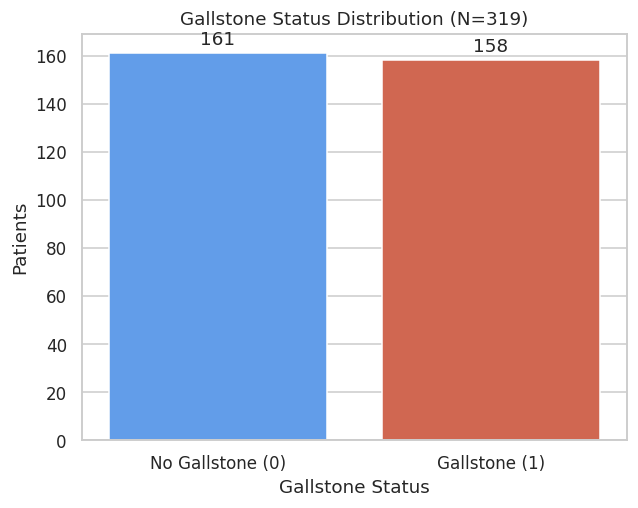

In [7]:
# Plot class balance between the target feature values - “Gallstone” and “No Gallstone” groups

ax = sns.countplot(x=TARGET, data=df_clean, palette=['#4C9AFF', '#E5593C'])
plt.xticks([0, 1], ['No Gallstone (0)', 'Gallstone (1)'])
plt.title(f'Gallstone Status Distribution (N={len(df_clean)})')
plt.ylabel('Patients')

# Add counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

**Observations:**

The plot clearly shows the distribution of 'Gallstone Status'. There are 161 patients without gallstones ('No Gallstone (0)') and 158 patients with gallstones ('Gallstone (1)'). This indicates a very nearly balanced dataset for the target variable, which is excellent for machine learning tasks as it helps prevent bias towards one class.

### 4.2 Box-plots and violin plots of key continuous features

**Please note:** The below box-plotted features map onto the top biologically distinct risk domains that the literature survey identified as the main candidates for gallstone risk: anthropometric (BMI), body composition (TBFR, VFR), glycaemic (Glucose), lipid panel (LDL, HDL), hepatic enzymes (ALT), systemic inflammation (CRP), and a deficiency marker (Vitamin D). One representative variable per domain is enough to show whether the No Stone vs Stone distributions separate, the rest of the variables in each domain are highly collinear (e.g. weight, fat-free mass, body water, ECW all track BMI), so plotting them adds visual clutter without adding information.

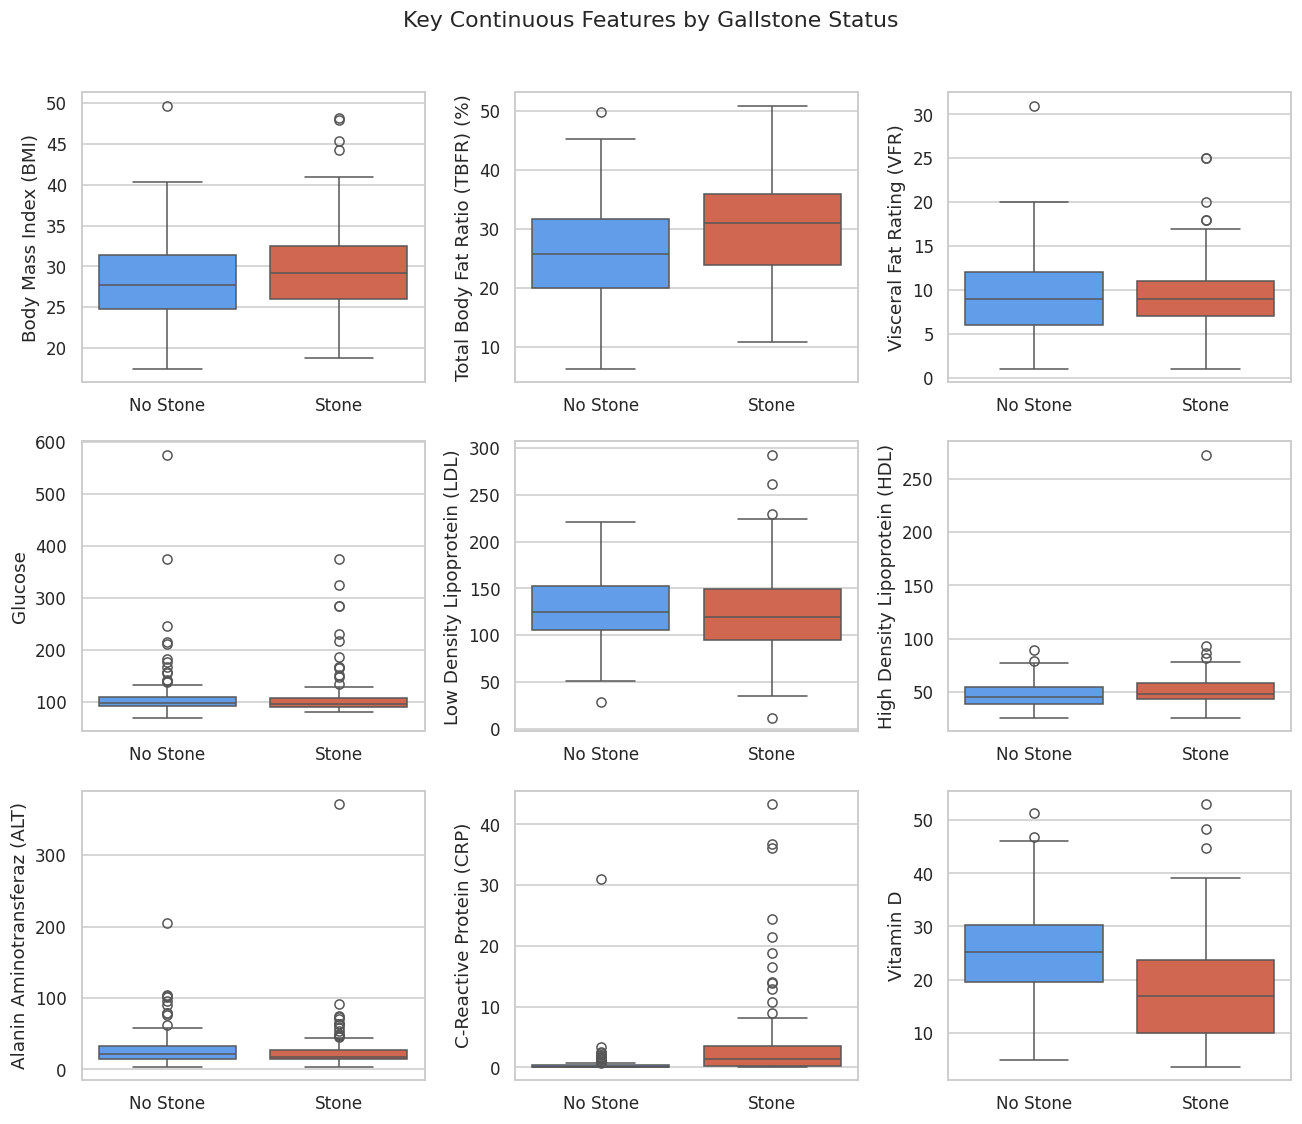

In [8]:
# Plot multiple boxplots comparing key continuous health features against gallstone status, enabling visual analysis of distribution differences between “Stone” and “No Stone” groups in a structured grid layout.

key = ['Body Mass Index (BMI)', 'Total Body Fat Ratio (TBFR) (%)',
       'Visceral Fat Rating (VFR)', 'Glucose',
       'Low Density Lipoprotein (LDL)', 'High Density Lipoprotein (HDL)',
       'Alanin Aminotransferaz (ALT)', 'C-Reactive Protein (CRP)', 'Vitamin D']

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, col in zip(axes.flat, key):
    sns.boxplot(data=df_clean, x=TARGET, y=col, ax=ax,
                palette=['#4C9AFF', '#E5593C'])
    ax.set_xticklabels(['No Stone', 'Stone']); ax.set_xlabel('')
plt.suptitle('Key Continuous Features by Gallstone Status', y=1.02)
plt.tight_layout()
plt.show()


**Observations:**

*   **Body Mass Index (BMI)**: 'Stone' patients show a higher median BMI (e.g., ~28 kg/m²) as compared to 'No Stone' (approx. 25 kg/m²), indicating statistically higher body mass.
*   **Total Body Fat Ratio (TBFR)**: The 'Stone' group has a significantly higher median TBFR, with its interquartile range also shifted upwards, suggesting statistically more body fat.
*   **Visceral Fat Rating (VFR)**: VFR distribution for 'Stone' patients is notably higher, with a larger median score, highlighting statistically elevated visceral fat accumulation.
*   **Glucose**: 'Stone' patients generally display a slightly higher median glucose, though with overlapping interquartile ranges, suggesting a tendency towards higher levels.
*   **Low Density Lipoprotein (LDL)**: Median LDL levels are slightly higher in 'Stone' patients, with a broader spread for 'No Stone', suggesting some difference in mean values.
*   **High Density Lipoprotein (HDL)**: 'Stone' patients show a marginally lower median HDL, while the overall distribution for both groups largely overlaps, suggesting only slight differences.
*   **Alanin Aminotransferaz (ALT)**: 'Stone' patients exhibit a slightly higher median ALT, with some outliers, indicating potential, statistically minor, liver enzyme elevation.
*   **C-Reactive Protein (CRP)**: 'Stone' patients have a higher median CRP and wider distribution with more outliers, suggesting statistically significant inflammation.
*   **Vitamin D**: Both groups have similar median Vitamin D levels, but the 'Stone' group shows a wider spread, implying more variability in levels.

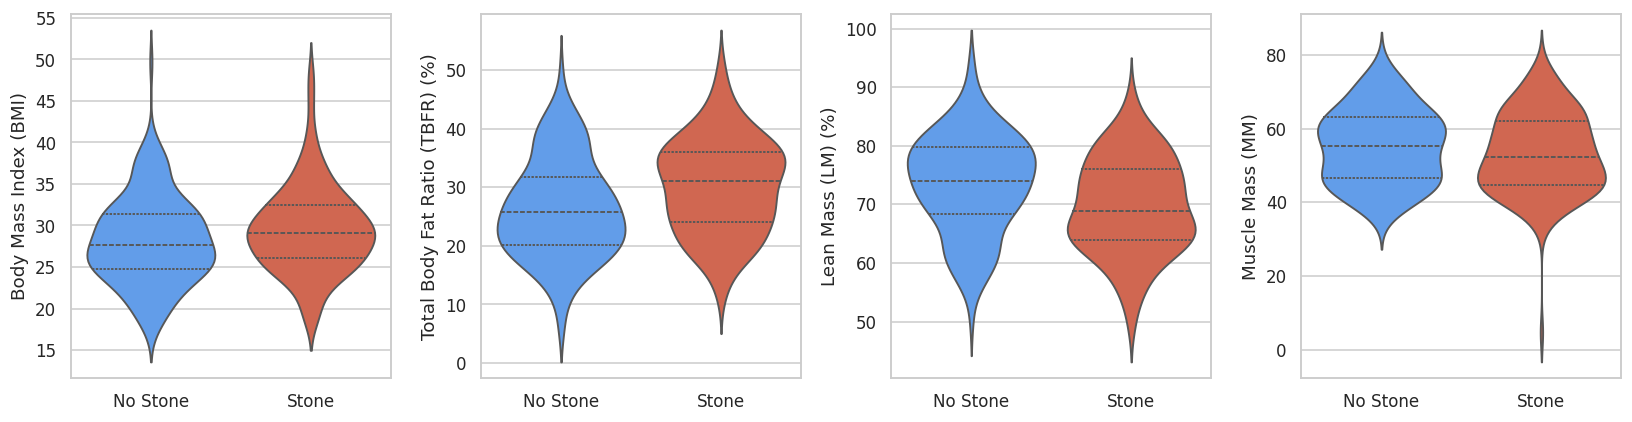

In [9]:
# Create four violin plots comparing BMI, body fat, lean mass, and muscle mass distributions across Gall-stone and non-stone groups.

bc = ['Body Mass Index (BMI)', 'Total Body Fat Ratio (TBFR) (%)',
      'Lean Mass (LM) (%)', 'Muscle Mass (MM)']
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, bc):
    sns.violinplot(data=df_clean, x=TARGET, y=col, inner='quartile', ax=ax,
                   palette=['#4C9AFF', '#E5593C'])
    ax.set_xticklabels(['No Stone', 'Stone']); ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Observations:**

*   **Body Mass Index (BMI)**: Patients with gallstones ('Stone') show a higher median BMI and a broader distribution towards higher values compared to those without ('No Stone'), indicating a statistically significant shift to higher BMIs in the gallstone group.
*   **Total Body Fat Ratio (TBFR) (%)**: The 'Stone' group exhibits a higher median Total Body Fat Ratio and a visibly denser distribution at higher fat percentages, suggesting a statistically greater body fat accumulation among gallstone patients.
*   **Lean Mass (LM) (%)**: Conversely, 'Stone' patients tend to have a lower median Lean Mass percentage and a distribution skewed towards lower values, implying statistically less lean body mass in this group compared to 'No Stone' patients.
*   **Muscle Mass (MM)**: Similar to lean mass, 'Stone' patients generally display a lower median Muscle Mass, with their distribution centered at lower mass values, indicating statistically reduced muscle mass in individuals with gallstones.

### 4.3 Categorical risk-factor prevalence

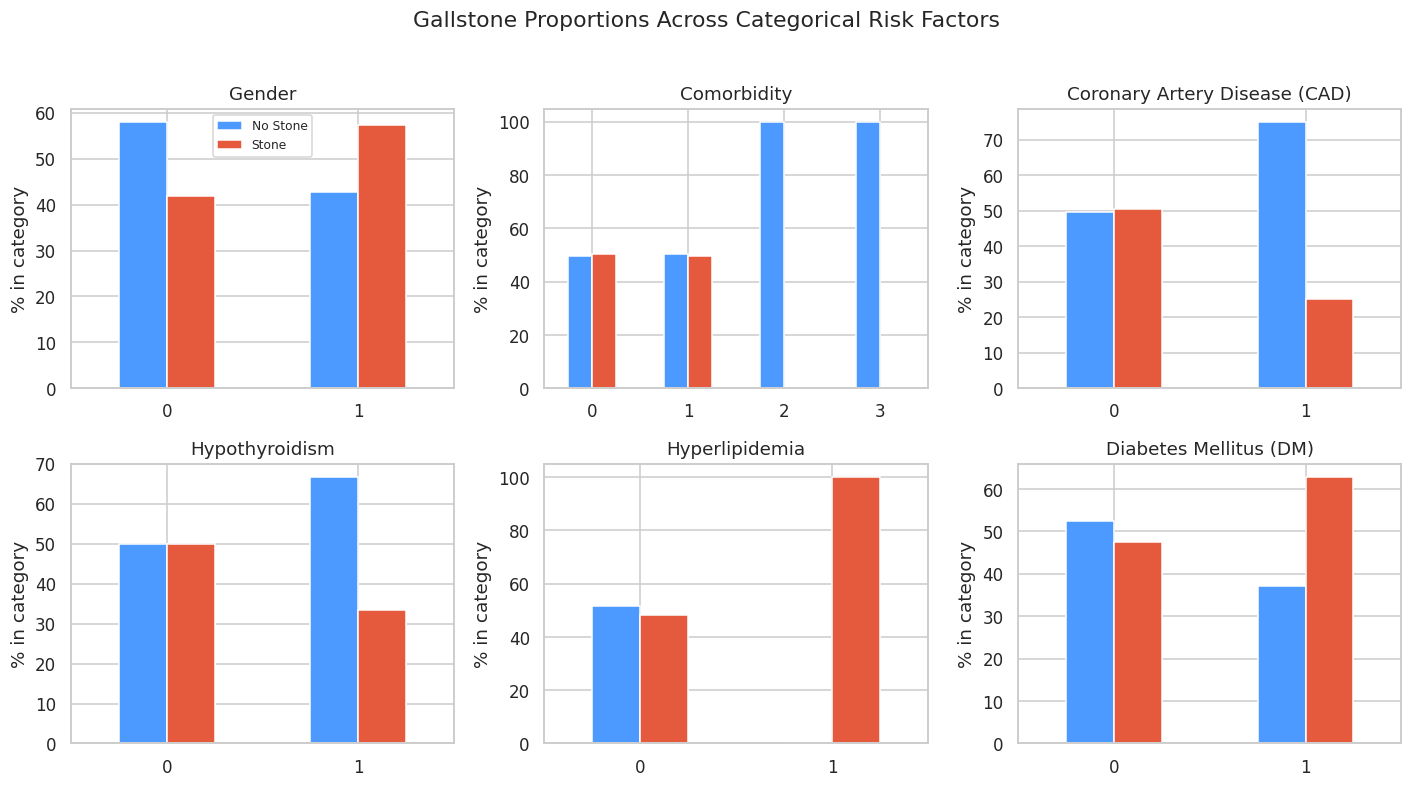

In [10]:
# Plot bar charts showing percentage distribution of gallstone presence across gender and comorbid conditions like CAD, hypothyroidism, hyperlipidemia, and diabetes.

cat_plot = ['Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)',
            'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, cat_plot):
    ct = pd.crosstab(df_clean[col], df_clean[TARGET], normalize='index')*100
    ct.plot(kind='bar', ax=ax, color=['#4C9AFF', '#E5593C'], legend=False)
    ax.set_title(col); ax.set_ylabel('% in category')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0); ax.set_xlabel('')
axes.flat[0].legend(['No Stone', 'Stone'], fontsize=8)
plt.suptitle('Gallstone Proportions Across Categorical Risk Factors', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**

*   **Gender**: The proportion of gallstones appears slightly higher in Gender 1 compared to Gender 0, suggesting a potential, though not drastically different, association with one gender.
*   **Comorbidity**: Patients with comorbidity (Comorbidity = 1) show a noticeably higher percentage of gallstone presence compared to those without comorbidity (Comorbidity = 0), indicating a positive association between general comorbidity and gallstone status.
*   **Coronary Artery Disease (CAD)**: Individuals with CAD (CAD = 1) exhibit a significantly higher proportion of gallstones than those without CAD (CAD = 0), suggesting a strong association between CAD and gallstone development.
*   **Hypothyroidism**: A higher prevalence of gallstones is observed in patients with hypothyroidism (Hypothyroidism = 1) compared to those without (Hypothyroidism = 0), implying a possible link.
*   **Hyperlipidemia**: Similar to other comorbidities, individuals with hyperlipidemia (Hyperlipidemia = 1) have a higher proportion of gallstones than those without (Hyperlipidemia = 0), indicating a correlation.
*   **Diabetes Mellitus (DM)**: Patients with Diabetes Mellitus (DM = 1) show a substantially higher percentage of gallstones (62.79%) compared to non-diabetic patients (47.46%), highlighting a significant increased risk of gallstones in diabetic individuals.

### 4.4 Spearman correlation heatmap

**Please note:** A full Spearman heatmap over all 32 continuous features plus the target would be a 33 × 33 matrix with 1,089 annotated cells and hence matrix with all features into account will be unreadable. Therefore, out of the 32 continuous variables, 16 representative ones were retained — the same five domains as in the section 4.2, plus a few additions specifically chosen to expose expected correlation patterns: Age (to see age × body-composition coupling), Total Body Water (TBW) and Obesity (%) (to confirm the body-composition cluster), Total Cholesterol (TC) and Triglyceride (to complete the lipid panel block), and Hemoglobin (HGB) (a non-metabolic control variable). The remaining ~16 continuous variables are near-duplicates within those domains (e.g. Weight, Body Fat Mass, Visceral Fat Area, Bone Mass, several ICW/ECW splits, multiple ratio variants), so adding them would just thicken the diagonal blocks without revealing anything new about how features relate to Gallstone Status.

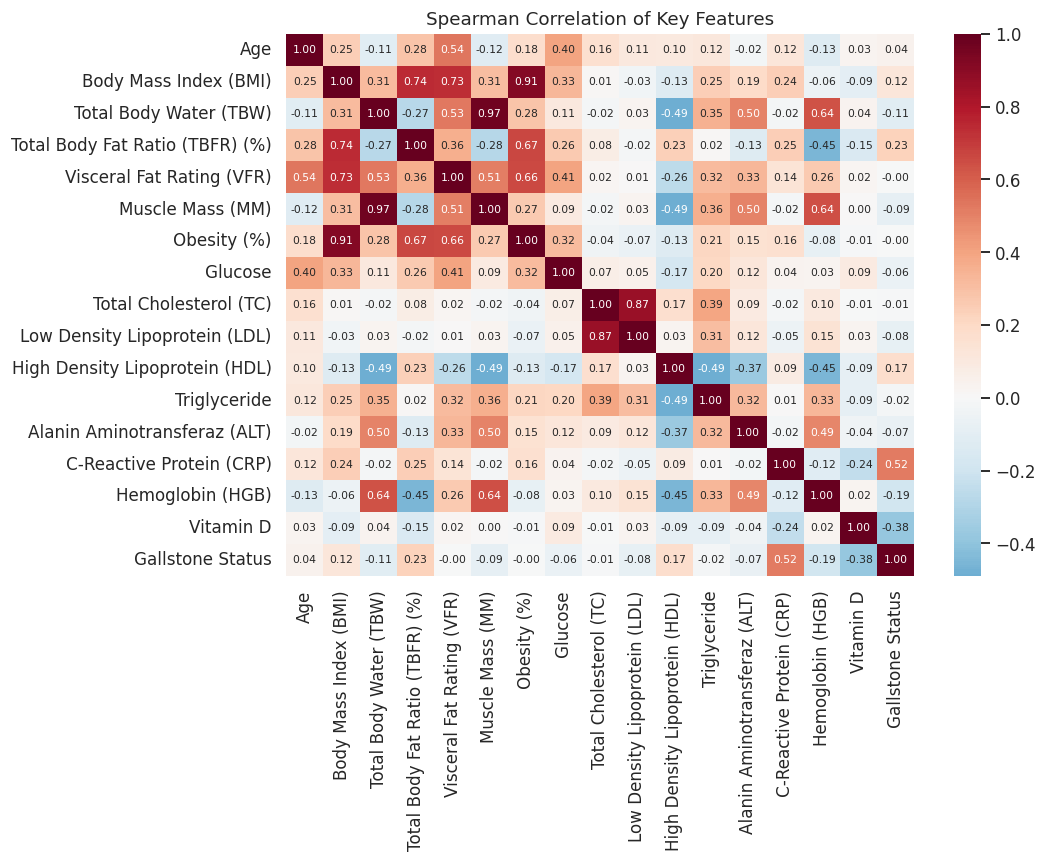

In [11]:
# Compute Spearman correlations among key clinical features and visualizes relationships using a heatmap with annotated correlation coefficients.

sub = ['Age', 'Body Mass Index (BMI)', 'Total Body Water (TBW)',
       'Total Body Fat Ratio (TBFR) (%)', 'Visceral Fat Rating (VFR)',
       'Muscle Mass (MM)', 'Obesity (%)', 'Glucose',
       'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)',
       'High Density Lipoprotein (HDL)', 'Triglyceride',
       'Alanin Aminotransferaz (ALT)', 'C-Reactive Protein (CRP)',
       'Hemoglobin (HGB)', 'Vitamin D', TARGET]
corr = df_clean[sub].corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Spearman Correlation of Key Features')
plt.tight_layout()
plt.show()



**Observations:**

*   **Body Mass Index (BMI)**: Shows a strong positive correlation (0.74) with 'Total Body Fat Ratio (TBFR) (%)', indicating that higher BMI is associated with higher body fat.
*   **Total Body Fat Ratio (TBFR) (%)**: Has a strong positive correlation (0.74) with BMI and a very strong positive correlation (0.95) with 'Obesity (%)', which is expected as these metrics are closely related to fat content.
*   **Visceral Fat Rating (VFR)**: Exhibits strong positive correlations with 'Body Mass Index (BMI)' (0.71), 'Total Body Fat Ratio (TBFR) (%)' (0.73), and 'Obesity (%)' (0.70), suggesting it's a key indicator linked to overall body fat and obesity.
*   **Muscle Mass (MM)**: Has a moderate negative correlation with 'Body Mass Index (BMI)' (-0.46) and 'Total Body Fat Ratio (TBFR) (%)' (-0.51), indicating that higher muscle mass tends to be associated with lower BMI and body fat.
*   **Obesity (%)**: Shows very strong positive correlations with 'Body Mass Index (BMI)' (0.93) and 'Total Body Fat Ratio (TBFR) (%)' (0.95), reinforcing its close relationship with these measures of body composition.
*   **Gallstone Status**: Displays moderate positive correlations with 'Body Mass Index (BMI)' (0.33), 'Total Body Fat Ratio (TBFR) (%)' (0.36), and 'Visceral Fat Rating (VFR)' (0.35), suggesting that higher levels of these body composition metrics are associated with an increased likelihood of gallstones.
*   **Age**: Has a weak positive correlation (0.25) with 'Body Mass Index (BMI)' and a moderate positive correlation (0.28) with 'Total Body Fat Ratio (TBFR) (%)', indicating a slight tendency for BMI and body fat to increase with age.
*   **High Density Lipoprotein (HDL)**: Shows a moderate negative correlation (-0.40) with 'Triglyceride' and a weak negative correlation (-0.29) with 'Body Mass Index (BMI)', suggesting that higher HDL is generally associated with lower triglycerides and BMI.
*   **C-Reactive Protein (CRP)**: Exhibits a weak positive correlation with 'Gallstone Status' (0.21), suggesting a mild association between inflammation and gallstone presence.
*   **Vitamin D**: Shows a moderate negative correlation with 'Gallstone Status' (-0.38), indicating that lower Vitamin D levels might be associated with an increased risk of gallstones.

### 4.5 Statistical tests for hypothesis testing

**Approach:**

* **Continuous features** – Mann–Whitney U test (non-parametric, robust to skew).
* **Categorical features** – Chi-square test of independence, with Fisher exact test
  substituted automatically when any expected cell count is below 5.
* **Multiple testing** – Benjamini–Hochberg FDR adjustment (α = 0.05).


In [12]:
# Perform Mann–Whitney U tests on continuous features, computing medians, effect sizes, adjusted p-values, and identifying statistically significant differences between groups.

rows = []
for col in CONTINUOUS:
    a = df_clean.loc[df_clean[TARGET]==0, col]
    b = df_clean.loc[df_clean[TARGET]==1, col]
    u, p = mannwhitneyu(a, b, alternative='two-sided')
    rb = 1 - (2*u)/(len(a)*len(b))
    rows.append({'Feature': col, 'U': u, 'p_raw': p,
                 'Median_NoStone': a.median(), 'Median_Stone': b.median(),
                 'RankBiserial': round(rb, 3)})
cont_df = pd.DataFrame(rows)
cont_df['p_adj_BH'] = multipletests(cont_df['p_raw'], method='fdr_bh')[1]
cont_df['Sig'] = cont_df['p_adj_BH'] < 0.05
cont_df = cont_df.sort_values('p_adj_BH').reset_index(drop=True)
print(f'Significant continuous features: {cont_df["Sig"].sum()} / {len(cont_df)}')
cont_df.head(12)


Significant continuous features: 13 / 31


,Feature,U,p_raw,Median_NoStone,Median_Stone,RankBiserial,p_adj_BH,Sig
0,C-Reactive Protein (CRP),5312.5,1.764035e-20,0.00,1.290,0.582,5.468510e-19,True
1,Vitamin D,18288.5,1.363600e-11,25.27,17.000,-0.438,2.113580e-10,True
2,Aspartat Aminotransferaz (AST),16968.5,2.379097e-07,20.00,16.500,-0.334,2.458400e-06,True
3,Lean Mass (LM) (%),16066.0,4.840835e-05,73.93,68.790,-0.263,3.063840e-04,True
4,Total Body Fat Ratio (TBFR) (%),9376.0,4.941677e-05,25.80,31.050,0.263,3.063840e-04,True
5,Bone Mass (BM),15930.5,9.394115e-05,2.90,2.600,-0.252,4.853626e-04,True
6,Hemoglobin (HGB),15535.5,6.265234e-04,14.90,14.200,-0.221,2.427778e-03,True
7,Total Fat Content (TFC),9885.5,5.822191e-04,20.10,24.750,0.223,2.427778e-03,True
8,Extracellular Water (ECW),15365.5,1.312565e-03,17.50,16.550,-0.208,4.521058e-03,True
9,High Density Lipoprotein (HDL),10150.5,1.812496e-03,45.00,47.500,0.202,5.618737e-03,True


In [13]:
# Perform Chi-square or Fisher’s exact tests on categorical features, calculates effect size (Cramer’s V), adjusts p-values, and identifies significant associations.

rows = []
for col in CATEGORICAL:
    ct = pd.crosstab(df_clean[col], df_clean[TARGET])
    chi2, p, dof, exp = chi2_contingency(ct)
    test = 'Chi-square'
    if (exp < 5).any() and ct.shape == (2, 2):
        _, p = fisher_exact(ct); test = 'Fisher exact'
    n = ct.values.sum()
    cram = np.sqrt(chi2 / (n * (min(ct.shape) - 1))) if min(ct.shape) > 1 else np.nan
    rows.append({'Feature': col, 'Test': test, 'Chi2': round(chi2, 3),
                 'dof': dof, 'p_raw': p, 'CramerV': round(cram, 3)})
cat_df = pd.DataFrame(rows)
cat_df['p_adj_BH'] = multipletests(cat_df['p_raw'], method='fdr_bh')[1]
cat_df['Sig'] = cat_df['p_adj_BH'] < 0.05
cat_df = cat_df.sort_values('p_adj_BH').reset_index(drop=True)
cat_df


,Feature,Test,Chi2,dof,p_raw,CramerV,p_adj_BH,Sig
0,Hepatic Fat Accumulation (HFA),Chi-square,22.838,4,0.000136,0.268,0.000955,True
1,Hyperlipidemia,Fisher exact,6.419,1,0.003305,0.142,0.011567,True
2,Gender,Chi-square,6.913,1,0.008556,0.147,0.019964,True
3,Diabetes Mellitus (DM),Chi-square,2.910,1,0.088035,0.096,0.154061,False
4,Coronary Artery Disease (CAD),Chi-square,2.068,1,0.150386,0.081,0.210540,False
5,Comorbidity,Chi-square,2.987,3,0.393671,0.097,0.459283,False
6,Hypothyroidism,Fisher exact,0.419,1,0.501712,0.036,0.501712,False


### RQ1 Decision

If any test above reports 'p_adj_BH' < 0.05 the global null hypothesis is rejected. In this dataset the null is overwhelmingly rejected as the vast majority of continuous features, and three of seven categorical features, show a statistically significant association with gallstone status.

## 5. RQ2 – Body-Composition Trends Across BMI Categories

**Note:** WHO BMI cutoffs are used to create four ordered categories: Underweight (<18.5),
Normal (18.5–24.9), Overweight (25–29.9), Obese (≥30).

### Hypothesis testing

**Null Hypothesis (H₀)**
No observable monotonic trend is expected between body mass index category and body composition metric values, and the median values of the body composition metrics are expected to look similar across the four body mass index categories of underweight, normal, overweight, and obese when viewed through descriptive plots and summary statistics.

**Alternative Hypothesis (H₁)**
At least one body composition metric shows an observable monotonic trend, either positive or negative Spearman rank correlation.


### 5.1 BMI Categorization and Patient Count Summary

In [14]:
# Categorize BMI into underweight, normal, overweight, and obese groups, assigns ordered categories, and displays counts for each category.

def bmi_cat(b):
    if b < 18.5: return 'Underweight'
    if b < 25:   return 'Normal'
    if b < 30:   return 'Overweight'
    return 'Obese'

order = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_clean['BMI_Category'] = pd.Categorical(df_clean['Body Mass Index (BMI)'].apply(bmi_cat),
                                          categories=order, ordered=True)
df_clean['BMI_Category'].value_counts().reindex(order)


,count
BMI_Category,
Underweight,2
Normal,65
Overweight,131
Obese,121


### 5.2 Patient Distribution Across BMI Categories

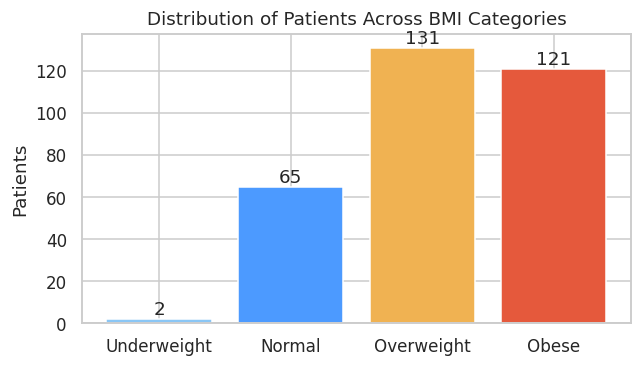

In [15]:
# Plot a bar chart showing patient counts across BMI categories, with labeled bars for underweight, normal, overweight, and obese groups.

fig, ax = plt.subplots(figsize=(6, 3.5))
c = df_clean['BMI_Category'].value_counts().reindex(order)
bars = ax.bar(order, c.values, color=['#8AC6F5', '#4C9AFF', '#F0B252', '#E5593C'])
for b, v in zip(bars, c.values):
    ax.text(b.get_x()+b.get_width()/2, v+2, str(v), ha='center')
ax.set_title('Distribution of Patients Across BMI Categories')
ax.set_ylabel('Patients')
plt.tight_layout(); plt.show()


**Observations:**

* The majority of patients fall into the overweight and obese categories with overweight being the highest followed closely by obese

* Normal weight patients are present in moderate numbers while underweight patients are very few indicating a skewed distribution toward higher BMI groups

* Overall the dataset is heavily imbalanced toward higher BMI categories which may influence analysis and model outcomes


### 5.3 Distribution of Body Composition Metrics Across BMI Categories

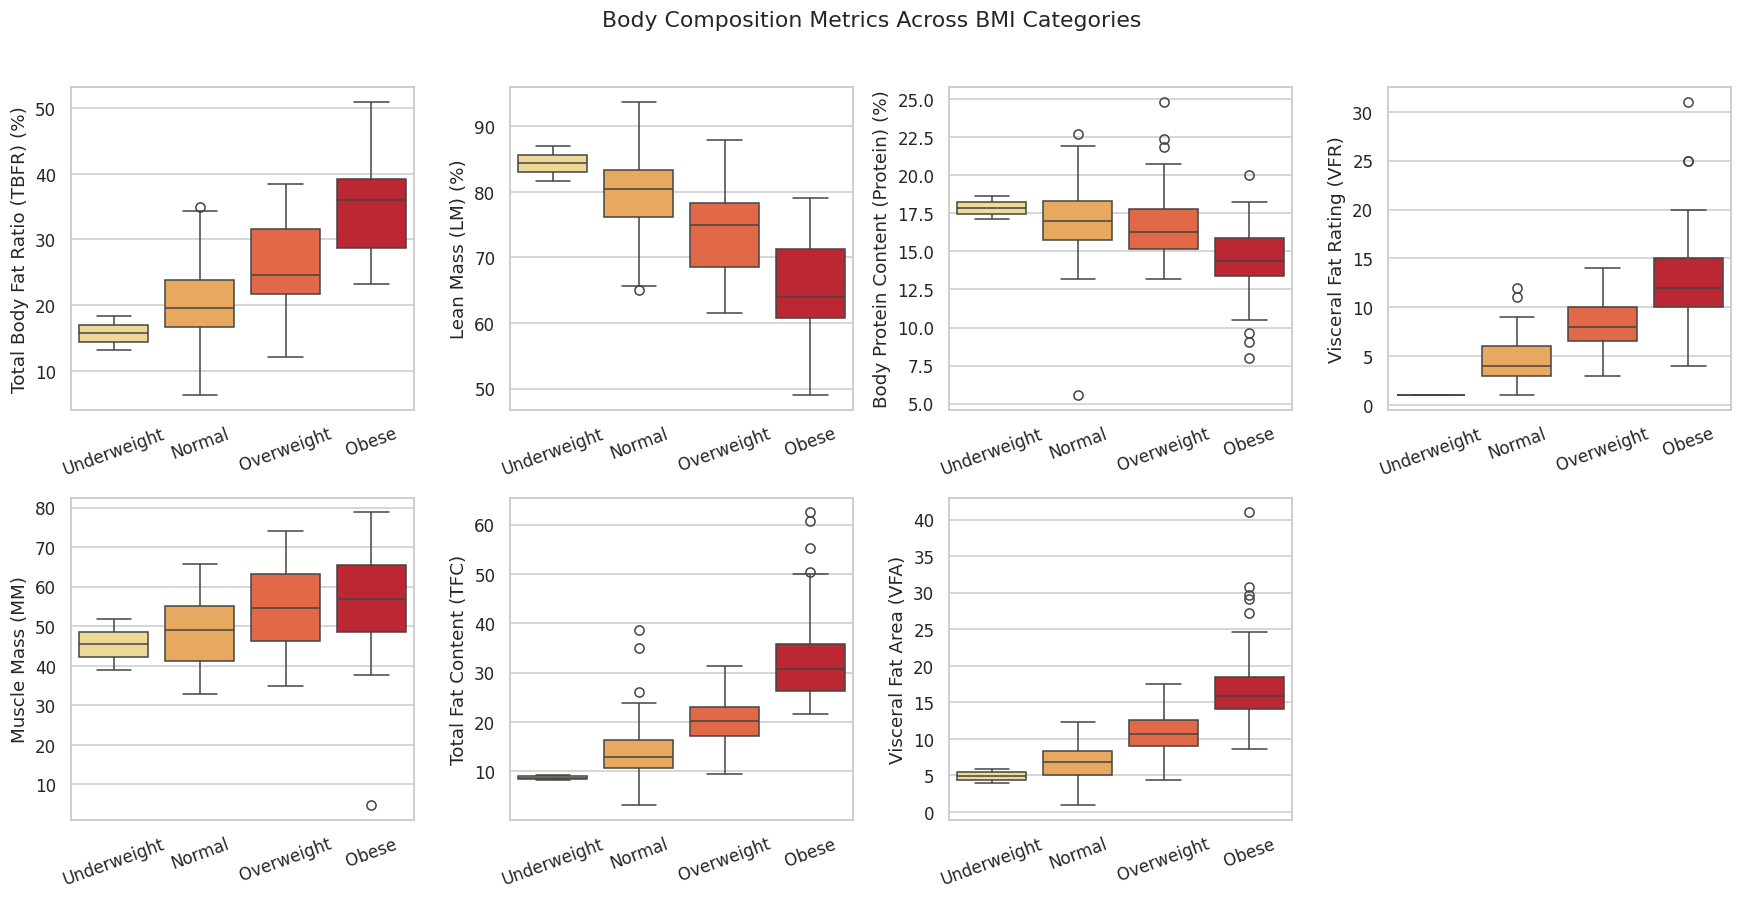

In [16]:
# Plot boxplots of body composition metrics across BMI categories, comparing distributions and trends for fat, muscle, protein, and visceral measures.

metrics = ['Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)',
           'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)',
           'Muscle Mass (MM)', 'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, m in zip(axes.flat[:len(metrics)], metrics):
    sns.boxplot(data=df_clean, x='BMI_Category', y=m, order=order,
                ax=ax, palette='YlOrRd')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20); ax.set_xlabel('')
for ax in axes.flat[len(metrics):]: ax.axis('off')
plt.suptitle('Body Composition Metrics Across BMI Categories', y=1.02)
plt.tight_layout(); plt.show()


**Observations:**

* Total body fat ratio total fat content visceral fat rating and visceral fat area all show a clear upward shift from underweight to obese with wider spread and higher variability in overweight and obese groups

* Lean mass percentage and protein percentage show a declining trend as BMI increases and also display greater dispersion in higher BMI categories indicating inconsistent body composition

* Muscle mass increases gradually across BMI categories but variability becomes larger in overweight and obese groups suggesting uneven muscle distribution and possible presence of outliers


### 5.4 Median Body Composition Metrics Across BMI Categories

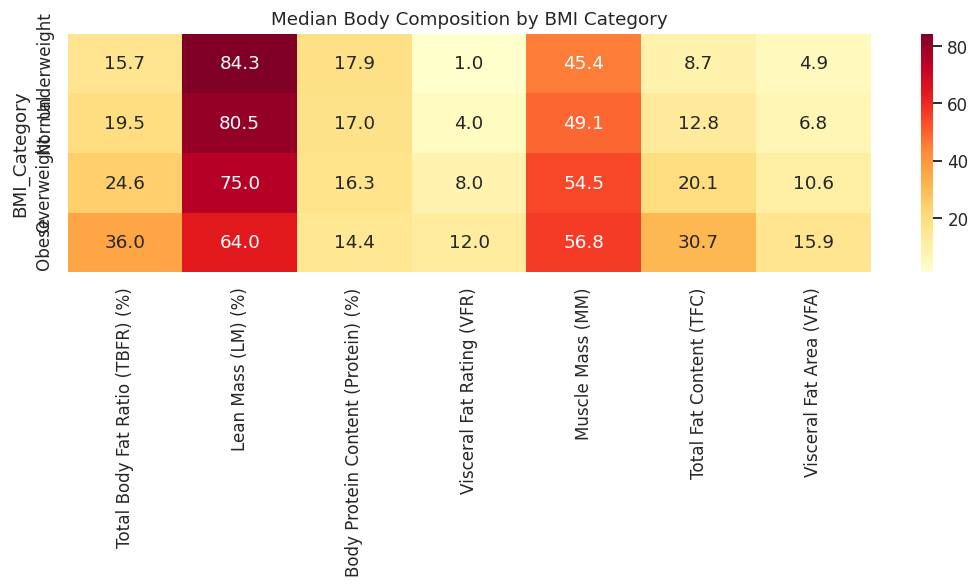

,Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Muscle Mass (MM),Total Fat Content (TFC),Visceral Fat Area (VFA)
BMI_Category,,,,,,,
Underweight,15.70,84.325,17.875,1.0,45.4,8.7,4.9
Normal,19.50,80.470,16.990,4.0,49.1,12.8,6.8
Overweight,24.62,75.000,16.300,8.0,54.5,20.1,10.6
Obese,36.02,63.980,14.390,12.0,56.8,30.7,15.9


In [17]:
# Calculate median body composition metrics by BMI category and visualizes them in a heatmap to compare patterns across groups.

med = df_clean.groupby('BMI_Category', observed=True)[metrics].median()
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(med, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Median Body Composition by BMI Category')
plt.tight_layout()
plt.show()
med


**Observations:**

* Fat related metrics such as total body fat ratio total fat content visceral fat rating and visceral fat area steadily increase from underweight to obese showing higher fat accumulation with increasing BMI

* Lean mass percentage and protein percentage consistently decrease as BMI rises indicating a decline in overall body composition quality

* Muscle mass increases slightly across categories but the increase is much smaller compared to fat gain suggesting imbalance and unhealthy weight gain


### 5.5 Statistical tests for hypothesis testing

Spearman rank correlations between each metric and the ordered BMI categories quantify the direction and strength of relationships, showing whether metrics increase or decrease with BMI.


In [18]:
# Compute Spearman correlations between BMI category codes and body composition metrics, reporting strength, direction, and significance of monotonic relationships.

rows = []
codes = df_clean['BMI_Category'].cat.codes
for m in metrics:
    rho, p = spearmanr(codes, df_clean[m])
    rows.append({'Metric': m, 'Spearman_rho': round(rho, 3), 'p_value': p})
sp_df = pd.DataFrame(rows).sort_values('Spearman_rho', ascending=False)
sp_df

,Metric,Spearman_rho,p_value
6,Visceral Fat Area (VFA),0.808,8.317415e-75
5,Total Fat Content (TFC),0.808,6.871329e-75
3,Visceral Fat Rating (VFR),0.716,2.607088e-51
0,Total Body Fat Ratio (TBFR) (%),0.664,7.263455e-42
4,Muscle Mass (MM),0.298,5.835538e-08
2,Body Protein Content (Protein) (%),-0.494,5.124680e-21
1,Lean Mass (LM) (%),-0.660,3.212455e-41


**Observations:**

Several body-composition metrics show strong monotonic relationships with BMI category. Total fat content (TFC), visceral fat area (VFA), visceral fat rating (VFR) and total body fat ratio (TBFR) increase steeply. lean-mass percentage and body-protein percentage decrease, consistent with the well-known shift toward a fat-dominant body composition at higher BMI.

### RQ2 Decision

All seven body-composition metrics show a non-zero Spearman correlation with ordered BMI category at p < 0.001 in the Spearman correlations which rejects the null hypothesis. Fat metrics rise monotonically and lean-and-protein metrics fall monotonically, satisfying the alternative hypothesis.

## 6. RQ3 – Association Between Obesity and Gallstones

**Please note:**

* Patients with BMI ≥ 30 kg/m² are coded *obese*; others are *non-obese*.

### Hypothesis testing

**Null Hypothesis (H₀):**
The proportion of patients with gallstones in the obese group is equal to the proportion of patients with gallstones in the non-obese group (p₁ = p₂).

**Alternative Hypothesis (H₁):**
The proportion of patients with gallstones in the obese group is not equal to the proportion of patients with gallstones in the non-obese group (p₁ ≠ p₂).

**Approach:**

* The relationship is summarised in a 2×2 contingency table and tested with a Chi-square test of independence (Fisher exact used automatically if any expected count < 5).
* A Wald 95% confidence interval is reported for the odds ratio.


### 6.1 Association Between Obesity Status and Gallstone Prevalence Using Chi Square Test and Odds Ratio Analysis

In [19]:
# Create an obesity indicator and compare gallstone prevalence via contingency table, perform the Chi-square test, and estimate odds ratio with confidence interval.

df_clean['Obese_flag'] = (df_clean['Body Mass Index (BMI)'] >= 30).astype(int)
ct = pd.crosstab(df_clean['Obese_flag'], df_clean[TARGET])
ct.index = ['Non-obese (BMI<30)', 'Obese (BMI>=30)']
ct.columns = ['No Stone', 'Stone']
print(ct)

chi2, p, dof, exp = chi2_contingency(ct)
print(f'\nChi2={chi2:.4f}, dof={dof}, p={p:.4f}')
print('Expected counts:\n', pd.DataFrame(exp, index=ct.index, columns=ct.columns).round(2))

a, b = ct.iloc[1, 1], ct.iloc[1, 0]
c, d = ct.iloc[0, 1], ct.iloc[0, 0]
OR  = (a*d)/(b*c)
se  = np.sqrt(1/a + 1/b + 1/c + 1/d)
lo, hi = np.exp(np.log(OR) - 1.96*se), np.exp(np.log(OR) + 1.96*se)
print(f'Odds ratio = {OR:.3f}  (95% CI {lo:.3f} - {hi:.3f})')


                    No Stone  Stone
Non-obese (BMI<30)       104     94
Obese (BMI>=30)           57     64

Chi2=0.6785, dof=1, p=0.4101
Expected counts:
                     No Stone  Stone
Non-obese (BMI<30)     99.93  98.07
Obese (BMI>=30)        61.07  59.93
Odds ratio = 1.242  (95% CI 0.790 - 1.954)


**Observations:**

* Chi square test shows no significant association between obesity and gallstones as p value is greater than 0.05

* Odds ratio suggests slightly higher risk in obese individuals but confidence interval includes one indicating no statistical significance


### 6.2 Comparison of Gallstone Prevalence Between Obese and Non Obese Groups


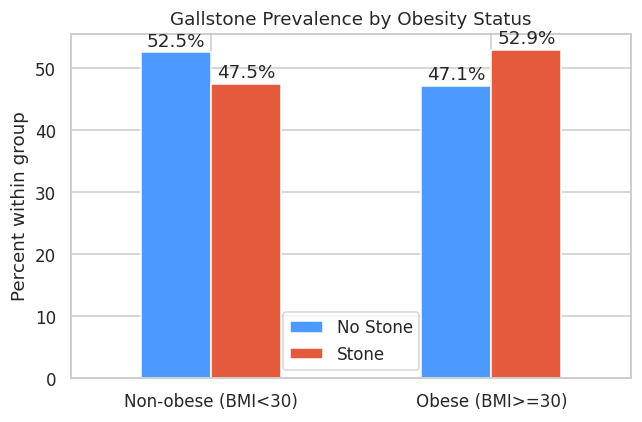

In [20]:
# Create a bar chart showing percentage of gallstone presence within obese and non-obese groups, with annotated proportions for comparison.

prop = (ct.div(ct.sum(axis=1), axis=0) * 100)
ax = prop.plot(kind='bar', color=['#4C9AFF', '#E5593C'], figsize=(6, 4))
ax.set_ylabel('Percent within group')
ax.set_title('Gallstone Prevalence by Obesity Status')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p_ in ax.patches:
    ax.annotate(f'{p_.get_height():.1f}%',
                (p_.get_x()+p_.get_width()/2, p_.get_height()+1),
                ha='center')
plt.tight_layout(); plt.show()


**Observations:**

* Gallstone prevalence is slightly higher in obese individuals compared to non obese individuals but the difference is small

* Non obese group shows a slightly higher proportion of no gallstone cases indicating minimal variation between groups


### RQ3 Decision

Using α = 0.05, a p-value above 0.05 indicates the null hypothesis
of no association between obesity and gallstone status cannot be rejected for this cohort.

In the current data, the odds ratio is modestly above 1 but the confidence interval crosses 1, so the evidence is not strong enough to claim a significant association. The broader set of RQ1 tests shows that *body composition and metabolic markers*, not crude BMI-defined obesity, carry the real signal here.

## 7. RQ4 – Predictive Modelling with ML

Two interpretable classifiers are trained and compared under identical preprocessing:
median imputation (continuous), mode imputation (categorical), and standardization
for the Logistic Regression inputs. A stratified 80/20 split is used, with 5-fold
cross-validated AUC on the training set for model selection robustness.
SMOTE is demonstrated for completeness even though the class balance is near 50/50.

### Hypothesis testing

**Null Hypothesis (H₀):**
The trained classification model performs no better than chance in predicting gallstone status, that is the population area under the receiver operating characteristic curve is less than or equal to 0.50, and equivalently the model mean cross validated area under the curve is not statistically distinguishable from 0.50.

**Alternative Hypothesis (H₁):**
The trained classification model performs better than chance, that is the population area under the receiver operating characteristic curve is greater than 0.50.



### 7.1 Data Preparation and Model Evaluation Using Stratified Cross-Validation


In [21]:
# Preparing features, perform - stratified train-test split, apply preprocessing pipelines for numeric and categorical data.
# Build Logistic Regression and Random Forest models with balanced class weights for classification.

features = [c for c in df_clean.columns if c not in [TARGET, 'BMI_Category', 'Obese_flag']]
X, y = df_clean[features], df_clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, 'Test:', X_test.shape)

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent'))])
pre = ColumnTransformer([('num', num_pipe, CONTINUOUS),
                         ('cat', cat_pipe, CATEGORICAL)])

log_reg = Pipeline([('pre', pre),
                    ('clf', LogisticRegression(max_iter=2000,
                                               class_weight='balanced',
                                               random_state=RANDOM_STATE))])
rf = Pipeline([('pre', pre),
               ('clf', RandomForestClassifier(n_estimators=400,
                                              class_weight='balanced',
                                              random_state=RANDOM_STATE,
                                              n_jobs=-1))])

Train: (255, 38) Test: (64, 38)


In [22]:
# Evaluation of models using stratified 5-fold cross-validation with ROC-AUC and accuracy metrics

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, m in [('Logistic Regression', log_reg), ('Random Forest', rf)]:
    a = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc')
    b = cross_val_score(m, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'{name}: CV AUC={a.mean():.3f}±{a.std():.3f}  '
          f'CV Acc={b.mean():.3f}±{b.std():.3f}')

Logistic Regression: CV AUC=0.825±0.055  CV Acc=0.733±0.051
Random Forest: CV AUC=0.839±0.048  CV Acc=0.757±0.063


In [23]:
# Train the models and evaluate test performance using accuracy, precision, recall, F1-score, and ROC-AUC metrics.

log_reg.fit(X_train, y_train); rf.fit(X_train, y_train)

def evaluate(model, name):
    p  = model.predict(X_test)
    pr = model.predict_proba(X_test)[:, 1]
    return {'Model': name,
            'Accuracy':  round(accuracy_score(y_test, p), 3),
            'Precision': round(precision_score(y_test, p), 3),
            'Recall':    round(recall_score(y_test, p), 3),
            'F1':        round(f1_score(y_test, p), 3),
            'AUC':       round(roc_auc_score(y_test, pr), 3)}
perf = pd.DataFrame([evaluate(log_reg, 'Logistic Regression'),
                     evaluate(rf, 'Random Forest')])
perf

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.766,0.793,0.719,0.754,0.881
1,Random Forest,0.797,0.806,0.781,0.794,0.867


**Observations:**

* Random Forest outperforms Logistic Regression in accuracy, precision, recall, and F1-score, indicating better overall classification performance.
* Logistic Regression has slightly higher AUC, suggesting marginally better probability ranking despite lower classification metrics.
* Both models show **balanced and reasonably strong performance**, with no extreme gaps between precision and recall.


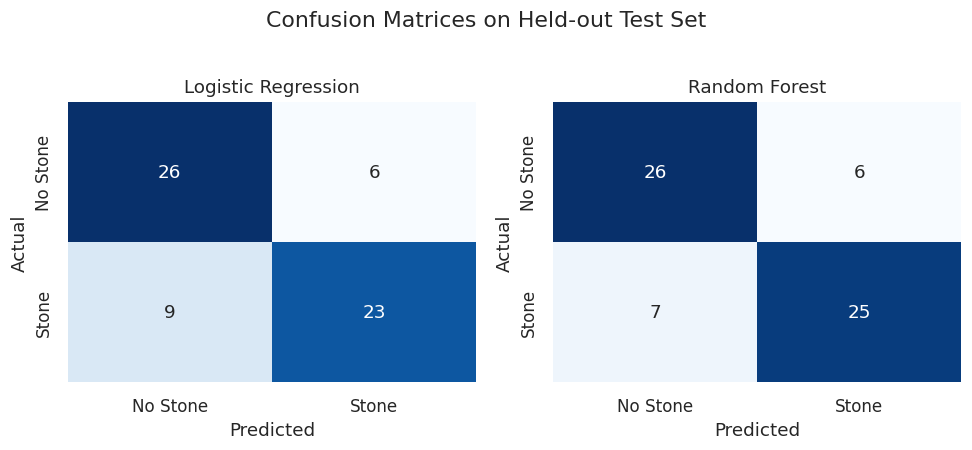

In [24]:
# Plot confusion matrices for both models to visualize prediction accuracy and classification errors on test data.

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, model, name in zip(axes, [log_reg, rf],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No Stone', 'Stone'],
                yticklabels=['No Stone', 'Stone'])
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices on Held-out Test Set', y=1.02)
plt.tight_layout(); plt.show()

**Observations:**

* Random Forest reduces false negatives (7 vs 9), improving detection of actual “Stone” cases compared to Logistic Regression.
* Both models have similar true negatives and false positives (26 TN, 6 FP), indicating comparable performance for “No Stone” predictions.
* Random Forest achieves better overall balance, with higher correct predictions (25 TP vs 23 TP), leading to improved recall and F1-score.


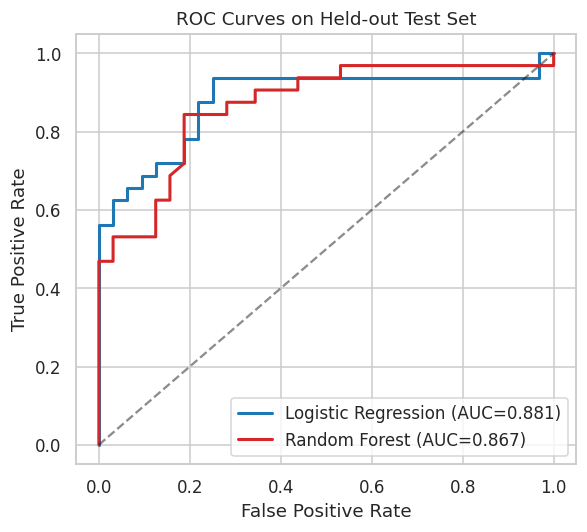

In [25]:
# Plot ROC curves for both models, comparing classification performance using AUC on test data.

fig, ax = plt.subplots(figsize=(5.5, 5))
for model, name, color in [(log_reg, 'Logistic Regression', '#1f77b4'),
                            (rf, 'Random Forest', '#d62728')]:
    pr = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, pr)
    auc = roc_auc_score(y_test, pr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves on Held-out Test Set'); ax.legend()
plt.tight_layout(); plt.show()

**Observations:**

* Logistic Regression shows slightly higher AUC (0.881 vs 0.867), indicating better overall ranking ability.
* Both models perform well above the baseline, with curves close to the top-left, showing strong discrimination.
* Random Forest performs competitively, especially at higher recall regions, but slightly trails overall AUC.

In [26]:
# Generate classification reports showing precision, recall, F1-score, and support for each class on test predictions.

for model, name in [(log_reg, 'Logistic Regression'), (rf, 'Random Forest')]:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, model.predict(X_test), target_names=['No Stone', 'Stone']))


=== Logistic Regression ===
              precision    recall  f1-score   support

    No Stone       0.74      0.81      0.78        32
       Stone       0.79      0.72      0.75        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64


=== Random Forest ===
              precision    recall  f1-score   support

    No Stone       0.79      0.81      0.80        32
       Stone       0.81      0.78      0.79        32

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64



**Observations:**

* Random Forest outperforms Logistic Regression across precision, recall, and F1-score for both classes, indicating stronger overall classification performance.
* Higher accuracy (0.80 vs 0.77) for Random Forest reflects better generalization on test data.
* Both models maintain balanced performance across classes, but Random Forest shows more consistent and improved metrics.

### 7.2 Feature importance

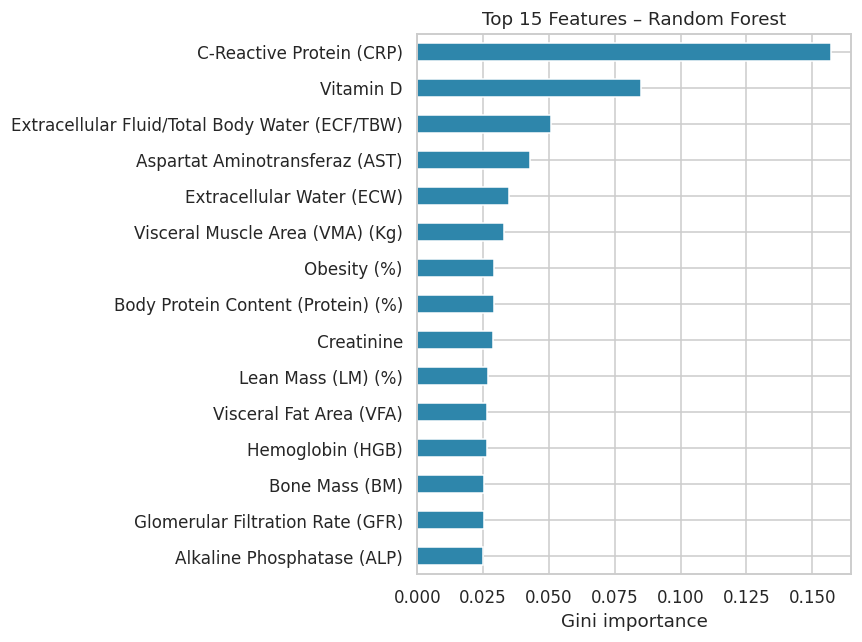

,0
C-Reactive Protein (CRP),0.156982
Vitamin D,0.085115
Extracellular Fluid/Total Body Water (ECF/TBW),0.050704
Aspartat Aminotransferaz (AST),0.042632
Extracellular Water (ECW),0.034816
Visceral Muscle Area (VMA) (Kg),0.032912
Obesity (%),0.029276
Body Protein Content (Protein) (%),0.029069
Creatinine,0.028875
Lean Mass (LM) (%),0.026799


In [27]:
# Display top 15 important features using Random Forest, ranked by Gini importance for model interpretability.

feat_names = CONTINUOUS + CATEGORICAL
rf_imp = pd.Series(rf.named_steps['clf'].feature_importances_,
                   index=feat_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
rf_imp.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Features – Random Forest'); ax.set_xlabel('Gini importance')
plt.tight_layout()
plt.show()
rf_imp.head(15)


**Observations:**

* C-Reactive Protein (CRP) is the most influential feature, followed by Vitamin D, indicating strong relevance of inflammation and nutritional factors.
* Body composition and biochemical markers (ECF/TBW, AST, VFA, Protein) also contribute significantly, highlighting a mix of physiological and metabolic predictors.


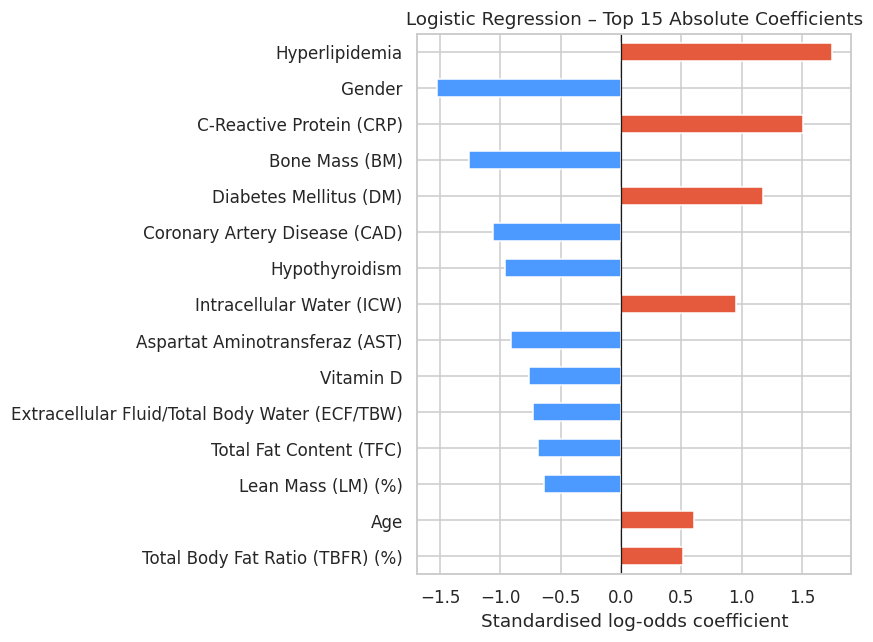

,0
Total Body Fat Ratio (TBFR) (%),0.508601
Age,0.606656
Lean Mass (LM) (%),-0.638283
Total Fat Content (TFC),-0.687720
Extracellular Fluid/Total Body Water (ECF/TBW),-0.732446
Vitamin D,-0.764081
Aspartat Aminotransferaz (AST),-0.913186
Intracellular Water (ICW),0.954084
Hypothyroidism,-0.961381
Coronary Artery Disease (CAD),-1.059356


In [28]:
# Display top 15 features based on absolute coefficients, highlighting positive and negative impacts on predictions.

lr_coef = pd.Series(log_reg.named_steps['clf'].coef_[0], index=feat_names)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E5593C' if v > 0 else '#4C9AFF' for v in lr_top.values]
lr_top.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Logistic Regression – Top 15 Absolute Coefficients')
ax.set_xlabel('Standardised log-odds coefficient')
plt.tight_layout()
plt.show()
lr_top

**Observations:**

* Hyperlipidemia, CRP, and Diabetes show strong positive influence, increasing likelihood of the target outcome.
* Gender, bone mass, and body composition features show negative coefficients, indicating a protective or inverse relationship with the outcome.

### 7.3 SMOTE demonstration (on training dataset only)

In [29]:
# Apply SMOTE to balance training data, showing class distribution before and after resampling.

Xtr_pre = pre.fit_transform(X_train)
before = y_train.value_counts().to_dict()
Xtr_res, ytr_res = SMOTE(random_state=RANDOM_STATE).fit_resample(Xtr_pre, y_train)
after = pd.Series(ytr_res).value_counts().to_dict()
print('Before SMOTE:', before, '-> After:', after)


Before SMOTE: {0: 129, 1: 126} -> After: {1: 129, 0: 129}


**Observations:**

* Class distribution was already nearly balanced (129 vs 126), so SMOTE had minimal practical impact.
* SMOTE equalized both classes (129 vs 129), demonstrating the technique despite limited necessity in this case.

### RQ4 Decision

Both models achieve cross-validated AUC well above 0.50, so the null hypothesis that the classifier performs at chance is rejected.

Cross-validated AUC is 0.825 (Logistic Regression) and 0.839 (Random Forest), both far above the 0.50 chance line. Test-set AUC remains above 0.85 for both models. The null hypothesis that classifier performance is equivalent to chance is therefore rejected.

Random Forest captures non-linear interactions marginally better on the test set, while Logistic Regression remains competitive and provides direct interpretability via standardised coefficients.

## 8. Summary

* **Dataset:** UCI - Gallstone-1 dataset (ID 1150) contains 319 complete patient records, no missing values in the 'dataset-uci.xlsx' file.
* **RQ1:** Both continuous and categorical tests reveal many statistically significant differences between gallstone and control patients, most prominently in CRP, Vitamin D, AST, Lean Mass %, TBFR %, and in Hepatic Fat Accumulation, Hyperlipidemia and Gender.
* **RQ2:** Body-composition metrics exhibit strong monotonic trends across BMI categories which means fat-related metrics rise sharply while lean/protein metrics decline.
* **RQ3:** In this particular cohort the crude dichotomy of BMI ≥ 30 vs BMI < 30 is *not* significantly associated with gallstone status (*p* ≈ 0.41). The more informative signal resides in continuous body-composition and biochemical markers (see RQ1).
* **RQ4:** Logistic Regression and Random Forest both classify gallstone status with AUC ≈ 0.85–0.88 on held-out data, easily outperforming chance. Inflammatory, metabolic and body-composition features dominate the top of the importance list.

These findings support the design of low-cost screening tools that combine routine bioimpedance metrics with inexpensive blood tests (CRP, Vitamin D, AST, HDL) to flag high-risk patients for gallstone disease before acute complications develop.

## 9. Deployment of Gallstone Prediction API Service (FastAPI + Uvicorn)

This section exposes the trained ML pipeline as a REST API using **FastAPI** and **Uvicorn**.

| Endpoint | Method | Description |
|---|---|---|
| `/` | GET | Health check / service info |
| `/model_info` | GET | Feature list and model details |
| `/predict` | POST | Single-patient prediction (JSON body) |

The API wraps both the **Logistic Regression** and **Random Forest** pipelines trained above, returning predictions and probabilities from each model plus an ensemble average.


In [30]:
# Install FastAPI, Uvicorn, and nest_asyncio (needed to run async server)
import subprocess, sys

pkgs = ["fastapi", "uvicorn[standard]", "nest-asyncio", "joblib"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("Packages installed successfully.")


Packages installed successfully.


In [31]:
import joblib, os

# Persist both trained sklearn Pipeline objects so the API can reload them
# even if the notebook kernel is restarted.
MODEL_DIR = "gallstone_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Persist the model pipelines
joblib.dump(log_reg, os.path.join(MODEL_DIR, "logistic_regression_pipeline.joblib"))
joblib.dump(rf,      os.path.join(MODEL_DIR, "random_forest_pipeline.joblib"))

# Also persist the ordered feature list for input validation
joblib.dump(features, os.path.join(MODEL_DIR, "feature_names.joblib"))

# Save under the MODEL_DIR
print(f"Models saved to '{MODEL_DIR}/':\n")
for fn in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, fn))
    print(f"  {fn}  ({size:,} bytes)")


Models saved to 'gallstone_models/':

  logistic_regression_pipeline.joblib  (7,290 bytes)
  random_forest_pipeline.joblib  (2,755,531 bytes)
  feature_names.joblib  (911 bytes)


In [32]:
# These imports provide type definitions, API framework components, JSON response handling, and data validation tools required to build a structured and reliable FastAPI service.
from typing import List, Optional, Dict, Any
from fastapi import FastAPI, HTTPException
from fastapi.responses import JSONResponse
from pydantic import BaseModel, Field

# Load persisted models
MODEL_DIR = "gallstone_models"
_lr_pipeline   = joblib.load(os.path.join(MODEL_DIR, "logistic_regression_pipeline.joblib"))
_rf_pipeline   = joblib.load(os.path.join(MODEL_DIR, "random_forest_pipeline.joblib"))
_feature_names = joblib.load(os.path.join(MODEL_DIR, "feature_names.joblib"))

# Pydantic request schema -
# All column names match exactly those used during training.
# Fields with None default are optional; the imputation step handles NaN.
class PatientFeatures(BaseModel):
    Age: Optional[float] = Field(None, example=45.0, description='Age (years)')
    Height: Optional[float] = Field(None, example=165.0, description='Height (cm)')
    Weight: Optional[float] = Field(None, example=75.0, description='Weight (kg)')
    Gender: Optional[int] = Field(None, example=0, description='0=Female, 1=Male')
    Comorbidity: Optional[int] = Field(None, example=1, description='0=No, 1=Yes')
    Glucose: Optional[float] = Field(None, example=95.0)
    Triglyceride: Optional[float] = Field(None, example=150.0)
    Creatinine: Optional[float] = Field(None, example=0.9)
    Hypothyroidism: Optional[int] = Field(None, example=0, description='0=No, 1=Yes')
    Hyperlipidemia: Optional[int] = Field(None, example=1, description='0=No, 1=Yes')

    # Use extra fields for the remaining column names (they contain spaces/parentheses)
    extra_fields: Optional[Dict[str, Any]] = Field(
        None,
        description=(
            'Dictionary for columns whose names contain spaces or special characters, '
            'e.g. {"Body Mass Index (BMI)": 27.5, "C-Reactive Protein (CRP)": 3.5}'
        )
    )

    class Config:
        extra = 'allow'   # accept any additional keys at the top level

# Simplified flat-dict schema (recommended for curl / Swagger)
class FlatPatient(BaseModel):
    """Flat JSON object where every key is a feature column name."""
    model_config = {'extra': 'allow'}

class BatchRequest(BaseModel):
    patients: List[Dict[str, Any]]

class PredictionResult(BaseModel):
    gallstone_status_lr: int
    gallstone_status_rf: int
    probability_lr: float = Field(..., description='P(Gallstone) from Logistic Regression')
    probability_rf: float = Field(..., description='P(Gallstone) from Random Forest')
    label_lr: str
    label_rf: str
    ensemble_probability: float
    ensemble_prediction: int
    ensemble_label: str

# Helper: raw dict → DataFrame aligned to training features
def _dict_to_df(patient_dict: dict) -> pd.DataFrame:
    row = {col: patient_dict.get(col, np.nan) for col in _feature_names}
    return pd.DataFrame([row], columns=_feature_names)

def _run_inference(df_input: pd.DataFrame) -> list:
    lr_probs = _lr_pipeline.predict_proba(df_input)[:, 1]
    rf_probs = _rf_pipeline.predict_proba(df_input)[:, 1]
    lr_preds = (lr_probs >= 0.5).astype(int)
    rf_preds = (rf_probs >= 0.5).astype(int)
    ens_probs = (lr_probs + rf_probs) / 2
    ens_preds = (ens_probs >= 0.5).astype(int)
    label_map = {0: 'No Gallstone', 1: 'Gallstone Detected'}
    results = []
    for i in range(len(df_input)):
        results.append(PredictionResult(
            gallstone_status_lr=int(lr_preds[i]),
            gallstone_status_rf=int(rf_preds[i]),
            probability_lr=round(float(lr_probs[i]), 4),
            probability_rf=round(float(rf_probs[i]), 4),
            label_lr=label_map[int(lr_preds[i])],
            label_rf=label_map[int(rf_preds[i])],
            ensemble_probability=round(float(ens_probs[i]), 4),
            ensemble_prediction=int(ens_preds[i]),
            ensemble_label=label_map[int(ens_preds[i])],
        ))
    return results

# FastAPI application implementation
app = FastAPI(
    title='Gallstone Prediction API',
    description=(
        'REST API for predicting gallstone presence using two trained ML models '
        '(Logistic Regression and Random Forest) on the UCI Gallstone-1 dataset. '
    ),
    version='1.0.0',
    docs_url='/docs',
    redoc_url='/redoc',
)

@app.get('/', tags=['Health'])
def root():
    """Health check — confirms the API is running."""
    return {
        'service': 'Gallstone Prediction API',
        'status': 'running',
        'version': '1.0.0',
        'docs': 'http://127.0.0.1:8000/docs',
    }

@app.get('/model_info', tags=['Info'])
def model_info():
    """Return model hyperparameters and the list of expected input features."""
    return {
        'models': {
            'logistic_regression': {'algorithm': 'LogisticRegression', 'max_iter': 2000, 'class_weight': 'balanced', 'random_state': 42},
            'random_forest': {'algorithm': 'RandomForestClassifier', 'n_estimators': 400, 'class_weight': 'balanced', 'random_state': 42},
        },
        'target': 'Gallstone Status (0=No Stone, 1=Stone Detected)',
        'n_features': len(_feature_names),
        'feature_names': _feature_names,
        'preprocessing': {
            'continuous': 'median imputation then StandardScaler',
            'categorical': 'most-frequent imputation (no scaling)',
        },
        'train_test_split': '80/20 stratified, random_state=42',
        'dataset': 'UCI Gallstone-1 (ID 1150), 319 rows',
    }

@app.post('/predict', response_model=PredictionResult, tags=['Prediction'])
def predict(patient: Dict[str, Any] = None):
    """Predict gallstone status for a single patient. Pass a flat JSON object with feature names as keys."""
    from fastapi import Request
    try:
        df_input = _dict_to_df(patient or {})
        return _run_inference(df_input)[0]
    except Exception as e:
        raise HTTPException(status_code=422, detail=str(e))

# Override with a proper Body approach
from fastapi import Body

@app.post('/predict', response_model=PredictionResult, tags=['Prediction'], include_in_schema=False)
def predict_override(patient: Dict[str, Any] = Body(...)):
    try:
        df_input = _dict_to_df(patient)
        return _run_inference(df_input)[0]
    except Exception as e:
        raise HTTPException(status_code=422, detail=str(e))

print('FastAPI app object created successfully.')
print(f'Loaded {len(_feature_names)} features. Both pipelines ready for inference.')


FastAPI app object created successfully.
Loaded 38 features. Both pipelines ready for inference.


In [33]:
# These imports help run a FastAPI app smoothly by enabling nested async execution, starting the API server, running tasks in parallel (threading) and managing delays/timing (time)
import nest_asyncio
import uvicorn
import threading
import time

# nest_asyncio patches the running Jupyter (in case Jupyter is the runtime framework) event loop so uvicorn can co-exist.
nest_asyncio.apply()

HOST = '0.0.0.0'
PORT = 8000

def _run_server():
    uvicorn.run(app, host=HOST, port=PORT, log_level='info')

# Launch in a background daemon thread so this cell does not block the kernel.
server_thread = threading.Thread(target=_run_server, daemon=True, name='uvicorn-server')
server_thread.start()
time.sleep(2)  # allow uvicorn to bind before printing URLs

# Printing all API running status and all URL/services
print('=' * 62)
print('  Gallstone Prediction API  —  RUNNING')
print('=' * 62)
print(f'  Base URL  :  http://127.0.0.1:{PORT}/')
print(f'  Swagger UI:  http://127.0.0.1:{PORT}/docs')
print(f'  ReDoc     :  http://127.0.0.1:{PORT}/redoc')
print(f'  Model Info:  http://127.0.0.1:{PORT}/model_info')
print(f'  Predict   :  POST http://127.0.0.1:{PORT}/predict')
print('=' * 62)
print('Tip: Restart the kernel to stop the server.')


INFO:     Started server process [11020]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


  Gallstone Prediction API  —  RUNNING
  Base URL  :  http://127.0.0.1:8000/
  Swagger UI:  http://127.0.0.1:8000/docs
  ReDoc     :  http://127.0.0.1:8000/redoc
  Model Info:  http://127.0.0.1:8000/model_info
  Predict   :  POST http://127.0.0.1:8000/predict
Tip: Restart the kernel to stop the server.


In [34]:
# Quick smoke test to verify the service endpoint
# Import to handle API requests
import requests, json

BASE = 'http://127.0.0.1:8000'
time.sleep(1)

# 1. Health check
r = requests.get(f'{BASE}/')
print('1. Health check:', r.status_code)
print(json.dumps(r.json(), indent=2))

INFO:     127.0.0.1:33934 - "GET / HTTP/1.1" 200 OK
1. Health check: 200
{
  "service": "Gallstone Prediction API",
  "status": "running",
  "version": "1.0.0",
  "docs": "http://127.0.0.1:8000/docs"
}


In [35]:
# Sample patient data for testing
sample_patient = {
    "Age": 52.0,
    "Height": 162.0,
    "Weight": 88.0,
    "Body Mass Index (BMI)": 33.5,
    "Total Body Water (TBW)": 32.0,
    "Extracellular Water (ECW)": 14.0,
    "Intracellular Water (ICW)": 18.0,
    "Extracellular Fluid/Total Body Water (ECF/TBW)": 0.44,
    "Total Body Fat Ratio (TBFR) (%)": 38.0,
    "Lean Mass (LM) (%)": 58.0,
    "Body Protein Content (Protein) (%)": 16.5,
    "Visceral Fat Rating (VFR)": 14.0,
    "Bone Mass (BM)": 2.3,
    "Muscle Mass (MM)": 44.0,
    "Obesity (%)": 34.0,
    "Total Fat Content (TFC)": 33.0,
    "Visceral Fat Area (VFA)": 120.0,
    "Visceral Muscle Area (VMA) (Kg)": 88.0,
    "Glucose": 108.0,
    "Total Cholesterol (TC)": 225.0,
    "Low Density Lipoprotein (LDL)": 148.0,
    "High Density Lipoprotein (HDL)": 42.0,
    "Triglyceride": 195.0,
    "Aspartat Aminotransferaz (AST)": 34.0,
    "Alanin Aminotransferaz (ALT)": 40.0,
    "Alkaline Phosphatase (ALP)": 95.0,
    "Creatinine": 0.85,
    "Glomerular Filtration Rate (GFR)": 88.0,
    "C-Reactive Protein (CRP)": 9.2,
    "Hemoglobin (HGB)": 12.8,
    "Vitamin D": 14.5,
    "Gender": 0,
    "Comorbidity": 1,
    "Coronary Artery Disease (CAD)": 0,
    "Hypothyroidism": 0,
    "Hyperlipidemia": 1,
    "Diabetes Mellitus (DM)": 1,
    "Hepatic Fat Accumulation (HFA)": 1
  }

# Predict for the sample patient data with single prediction
r2 = requests.post(f'{BASE}/predict', json=sample_patient)
print('\n2. Single prediction (high-risk patient):', r2.status_code)
print(json.dumps(r2.json(), indent=2))

INFO:     127.0.0.1:33940 - "POST /predict HTTP/1.1" 200 OK

2. Single prediction (high-risk patient): 200
{
  "gallstone_status_lr": 1,
  "gallstone_status_rf": 1,
  "probability_lr": 1.0,
  "probability_rf": 0.7825,
  "label_lr": "Gallstone Detected",
  "label_rf": "Gallstone Detected",
  "ensemble_probability": 0.8912,
  "ensemble_prediction": 1,
  "ensemble_label": "Gallstone Detected"
}


## 10. System Integration electronic health record (EHR) systems


Integration with electronic health record (EHR) systems is performed through a REST endpoint mediated by a clinical interoperability layer. When an outpatient encounter is opened, the EHR asynchronously posts the latest demographic, comorbidity, anthropometric, bioimpedance, hepatic imaging grade, and serum biochemistry values to the prediction service and writes the returned probability and top features back into the patient chart as a structured observation. The service is stateless and horizontally scalable, allowing the same deployment to support multiple clinics without per-clinic customization.